In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_excel("Hotel_Revenue_Data.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120562 entries, 0 to 120561
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date               120562 non-null  datetime64[ns]
 1   MealPeriod         120562 non-null  object        
 2   CheckTotal         120562 non-null  float64       
 3   RevenueCenterName  120562 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.7+ MB


In [4]:
print(df.head())


        Date MealPeriod  CheckTotal RevenueCenterName
0 2023-04-18     Dinner       125.0   RevenueCenter_1
1 2023-04-18     Dinner        37.5   RevenueCenter_1
2 2023-04-18     Dinner         0.0   RevenueCenter_1
3 2023-04-18     Dinner         0.0   RevenueCenter_1
4 2023-04-18     Dinner        70.0   RevenueCenter_2


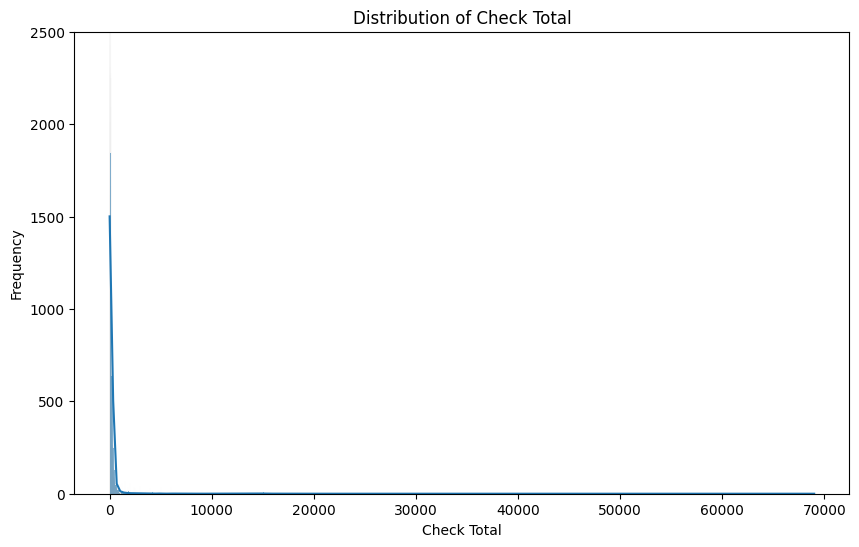

In [5]:
#Univariate Analysis
# Histogram of Check Total
plt.figure(figsize=(10, 6))
sns.histplot(df['CheckTotal'], kde=True)
plt.title('Distribution of Check Total')
plt.xlabel('Check Total')
plt.ylabel('Frequency')
plt.ylim(0, 2500)
plt.show()

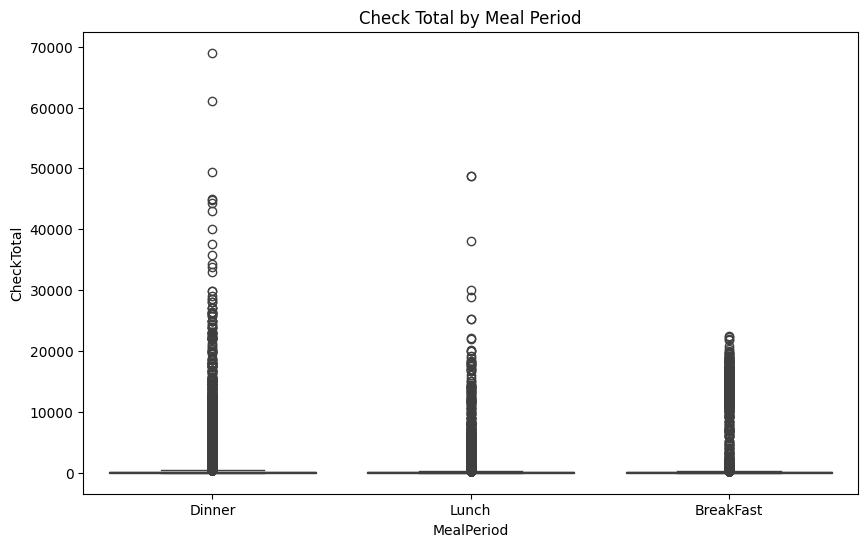

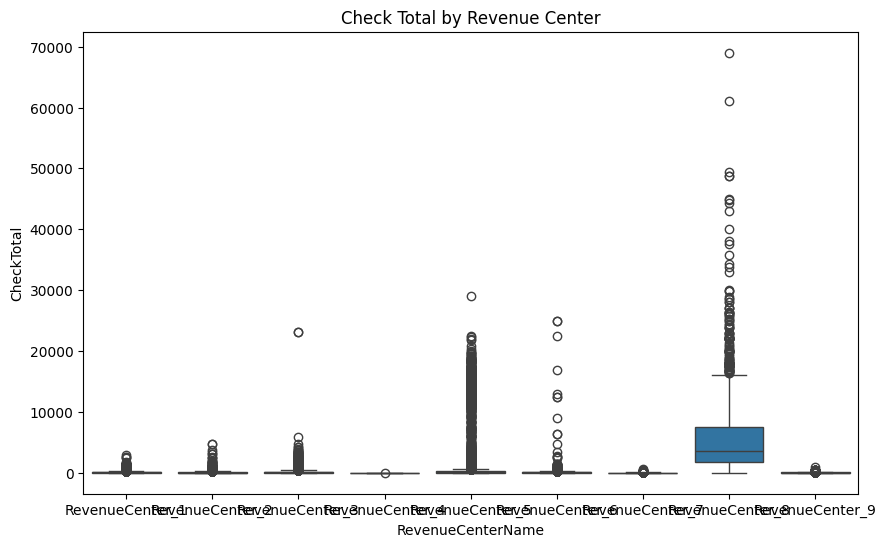

In [6]:
#Bivariate Analysis
# Box plot of Check Total by Meal Period
plt.figure(figsize=(10, 6))
sns.boxplot(x='MealPeriod', y='CheckTotal', data=df)
plt.title('Check Total by Meal Period')
plt.show()

# Box plot of Check Total by Revenue Center
plt.figure(figsize=(10, 6))
sns.boxplot(x='RevenueCenterName', y='CheckTotal', data=df)
plt.title('Check Total by Revenue Center')
plt.show()

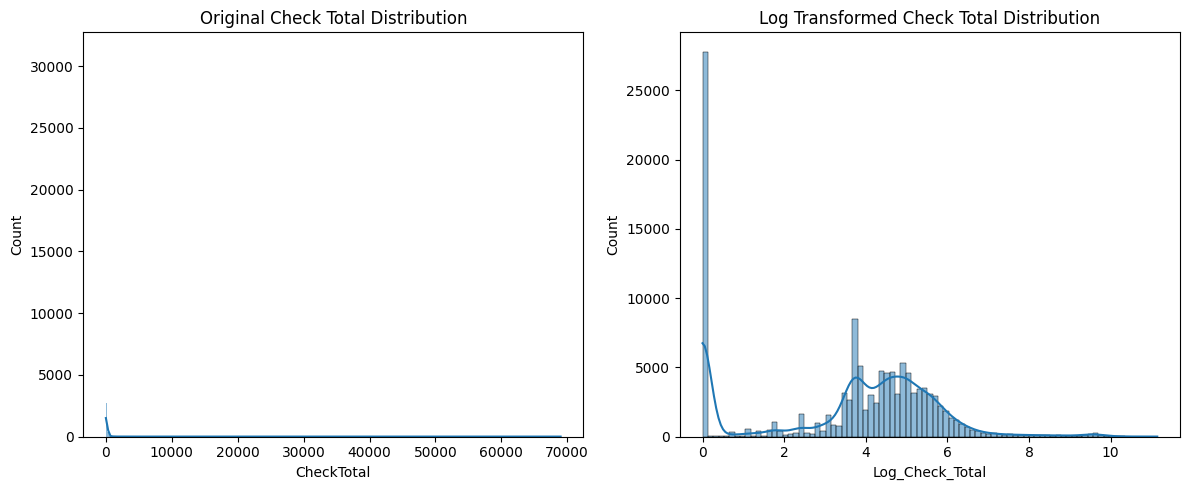

In [7]:
# Create a new column by applying the natural logarithm transformation
# We use np.log1p(x) (which computes log(1+x)) to safely handle any potential zero values in the 'Check Total'
df['Log_Check_Total'] = np.log1p(df['CheckTotal'])

# Visualize the new distribution to see the effect
plt.figure(figsize=(12, 5))

# Original data distribution (often highly skewed)
plt.subplot(1, 2, 1)
sns.histplot(df['CheckTotal'], kde=True)
plt.title('Original Check Total Distribution')

# Transformed data distribution (should be less skewed)
plt.subplot(1, 2, 2)
sns.histplot(df['Log_Check_Total'], kde=True)
plt.title('Log Transformed Check Total Distribution')

plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import requests
from datetime import datetime
from tqdm import tqdm
import time
from google import genai
from google.genai import types
from dotenv import load_dotenv 

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY') 
CALENDARIFIC_API_KEY = os.getenv('CALENDARIFIC_API_KEY')

# Check for keys and raise an error if they are missing
if not GEMINI_API_KEY or not CALENDARIFIC_API_KEY:
    raise ValueError("API Keys not found. Please ensure GEMINI_API_KEY and CALENDARIFIC_API_KEY are set correctly in your .env file.")

# Set the environment variable for Gemini's automatic detection (optional but helpful)
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY 

CALENDARIFIC_API_URL = "https://calendarific.com/api/v2/holidays"

# --- HOLIDAY FUNCTIONS (Intelligent Feature Generation with Caching) ---
def is_uae_related_holiday(name_of_holiday: str) -> dict:
    """Determine if holiday affects hotels/restaurants in UAE."""
    try:
        client = genai.Client(api_key=GEMINI_API_KEY)
    except Exception as e:
        print(f"Error initializing Gemini client: {e}")
        return {"does_affect": False, "affect_type": "Public"}
        
    system_prompt = (
        "You are an expert holiday classification assistant focused on the UAE. "
        "Your task is to analyze the provided holiday name and determine if it is likely to significantly "
        "affect customer flow (increase or decrease) to hotels and restaurants in the UAE. "
        "You MUST return the result as a single, valid JSON object following the format: "
        "{'does_affect': True/False, 'affect_type': 'Islamic'/'Public'}." 
        "Do not include any other text, explanation, or conversational fillers. Only output JSON."
    )

    user_prompt = f"Does the holiday '{name_of_holiday}' affect people to come to hotels/restaurants in the UAE?"
    
    config = types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=types.Schema(
            type=types.Type.OBJECT,
            properties={
                "does_affect": types.Schema(type=types.Type.BOOLEAN, description="True if the holiday affects traffic."),
                "affect_type": types.Schema(type=types.Type.STRING, description=" Islamic, or Public."),
            },
            required=["does_affect", "affect_type"],
        ),
        system_instruction=system_prompt,
    )

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[user_prompt],
            config=config,
        )
        time.sleep(6)
        output = response.text
        return json.loads(output) if output else {"does_affect": False, "affect_type": "Public"}
    except Exception as e:
        print(f"Gemini API error for {name_of_holiday}: {e}")
        return {"does_affect": False, "affect_type": "Public"}


def get_holidays_api(year: int, country: str) -> list:
    """Retrieve holidays for a given year and country."""
    params = {
        "api_key": CALENDARIFIC_API_KEY,
        "country": country,
        "year": year,
    }
    
    try:
        response = requests.get(CALENDARIFIC_API_URL, params=params, timeout=10)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching holidays for {country} in {year}: {e}")
        return []

    if response.status_code != 200:
        print(f"Error: Status {response.status_code}")
        return []
        
    try:
        holidays = response.json()["response"]["holidays"]
    except (json.JSONDecodeError, KeyError):
        print(f"Error parsing holiday data for {country} in {year}")
        return []
        
    refined_holidays = []
    for holiday in holidays:
        holiday_date = datetime.strptime(holiday["date"]["iso"][:10], "%Y-%m-%d")
        x = {
            "name": holiday["name"],
            "date": holiday_date.strftime("%Y-%m-%d"),
            "country": country,
        }
        if x not in refined_holidays:
            refined_holidays.append(x)
    return refined_holidays


def get_holidays_from_data(start_date: datetime, end_date: datetime) -> list:
    """Retrieve and process UAE holidays that affect hotels/restaurants with robust caching."""
    
    prev_holidays = []
    if os.path.exists("holidays.json"):
        with open("holidays.json", "r") as f:
            prev_holidays = json.load(f)
    
    cached_years = set()
    if prev_holidays:
        for h in prev_holidays:
            year = datetime.strptime(h["date"], "%Y-%m-%d").year
            cached_years.add(year)
    
    required_years = set(range(start_date.year, end_date.year + 1))
    missing_years = sorted(required_years - cached_years)
    
    new_holidays = []
    if missing_years:
        print(f"Fetching holidays for years: {missing_years}")
        for year in missing_years:
            ae_holidays = get_holidays_api(year, "AE")
            new_holidays.extend(ae_holidays)
        
        processed_new_holidays = []
        for holiday in tqdm(new_holidays, desc="Processing new holidays with Gemini"):
            result = is_uae_related_holiday(holiday["name"])
            if result["does_affect"]:
                processed_new_holidays.append({
                    "name": holiday["name"],
                    "date": holiday["date"],
                    "affect_type": result["affect_type"],
                    "country": holiday["country"],
                })
    else:
        print("All required years found in cache. No API calls needed.")
        processed_new_holidays = []
    
    all_holidays = prev_holidays + processed_new_holidays
    
    unique_holidays = []
    seen_identifiers = set()
    for h in all_holidays:
        identifier = (h['name'], h['date'], h['country'])
        if identifier not in seen_identifiers:
            unique_holidays.append(h)
            seen_identifiers.add(identifier)
    
    unique_holidays = sorted(unique_holidays, key=lambda x: x["date"])
    
    with open("holidays.json", "w") as f:
        json.dump(unique_holidays, f, indent=2)
    
    filtered_holidays = [
        h for h in unique_holidays
        if start_date.strftime("%Y-%m-%d") <= h["date"] <= end_date.strftime("%Y-%m-%d")
    ]
    
    return filtered_holidays

In [18]:
DATE_COLUMN = 'Date'
CHECK_TOTAL_COLUMN = 'Check Total'

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df['DateKey'] = df[DATE_COLUMN].dt.date

start_date = df[DATE_COLUMN].min()
end_date = df[DATE_COLUMN].max()

relevant_holidays = get_holidays_from_data(start_date, end_date)

# One-Hot Encode Meal Period and Revenue Center Name (CRITICAL for aggregation)
df_final = pd.get_dummies(df, columns=['MealPeriod', 'RevenueCenterName'], prefix=['MealPeriod', 'RevenueCenter'], drop_first=False)

All required years found in cache. No API calls needed.


In [22]:
import warnings
from datetime import date

warnings.filterwarnings('ignore') 

# --- UTILITY FUNCTION FOR DENSIFICATION SKELETON ---

def create_date_feature_skeleton(start: date, end: date, holidays: list) -> pd.DataFrame:
    """
    Creates a continuous calendar DataFrame (the 'skeleton') for the required date range.
    
    This function computes ALL necessary temporal and event features directly on the date keys, 
    ensuring that even missing dates are filled with correct feature values (e.g., IsWeekend=1, Month=5).
    """
    
    start_dt = datetime.combine(start, datetime.min.time())
    end_dt = datetime.combine(end, datetime.min.time())
    full_range = pd.date_range(start=start_dt, end=end_dt, freq='D')
    skeleton = pd.DataFrame({'Date': full_range})
    skeleton['DateKey'] = skeleton['Date'].dt.date
    
    # calculate ALL Temporal and Advanced Features for the continuous date range
    skeleton['Month'] = skeleton['Date'].dt.month
    skeleton['WeekOfMonth'] = (skeleton['Date'].dt.day - 1) // 7 + 1
    skeleton['DayOfMonth'] = skeleton['Date'].dt.day
    skeleton['IsWeekend'] = skeleton['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0) 
    skeleton['IsMonthStart'] = (skeleton['DayOfMonth'] <= 5).astype(int) 
    skeleton['IsMonthEnd'] = (skeleton['DayOfMonth'] >= 25).astype(int) 
    skeleton = skeleton.drop('DayOfMonth', axis=1)
    
    # Recalculate HOLIDAY features using the classified list
    holiday_dict = {h['date']: h['affect_type'] for h in holidays}
    skeleton['HolidayType'] = skeleton['Date'].dt.strftime('%Y-%m-%d').map(holiday_dict)

    skeleton['IsHoliday_Islamic'] = (skeleton['HolidayType'] == 'Islamic').astype(int)
    skeleton['IsHoliday_Public'] = (skeleton['HolidayType'] == 'Public').astype(int)
    skeleton = skeleton.drop('HolidayType', axis=1)
    # General holiday flag (IsHoliday)
    skeleton['IsHoliday'] = skeleton[['IsHoliday_Islamic', 'IsHoliday_Public']].max(axis=1)
    
    # calculate Day-of-Week features (One-Hot Encoded)
    days_of_week_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    days_of_week_cols = ['IsMonday', 'IsTuesday', 'IsWednesday', 'IsThursday', 'IsFriday', 'IsSaturday', 'IsSunday']
    skeleton['DayName'] = skeleton['Date'].dt.day_name()
    for day_col, day_name in zip(days_of_week_cols, days_of_week_names):
        skeleton[day_col] = (skeleton['DayName'] == day_name).astype(int)
    skeleton = skeleton.drop(['DayName', 'Date'], axis=1) 

    return skeleton.set_index('DateKey')

print("✅ Utility function 'create_date_feature_skeleton' defined.")

✅ Utility function 'create_date_feature_skeleton' defined.


In [23]:
#  DENSIFICATION AND EXPORT LOGIC

df_report = df_final.copy() # Creates an independent copy of the feature-engineered data to safely add temporary columns 

# 1. Prepare Targets and Columns
# Convert log-transformed check total back to raw revenue for summation
df_report['Check_Total_Revenue'] = np.expm1(df_report['Log_Check_Total'])

REVENUE_BREAKDOWN_COLS_NAMES = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']
OUTPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Create transaction-level revenue breakdown
meal_period_cols = [col for col in df_report.columns if col.startswith('MealPeriod_')]
revenue_center_cols = [col for col in df_report.columns if col.startswith('RevenueCenter_')]

for meal_col in meal_period_cols:
    meal_name = meal_col.split("_")[-1] 
    df_report[f'Revenue_By_{meal_name}'] = df_report['Check_Total_Revenue'] * df_report[meal_col].astype(int)

# 2. Create the master feature skeleton
start_date_dt = df_report['DateKey'].min()
end_date_dt = df_report['DateKey'].max()

feature_skeleton = create_date_feature_skeleton(start_date_dt, end_date_dt, relevant_holidays) 
SKELETON_FEATURE_COLS = list(feature_skeleton.columns)

print(f"\n Starting export of 9 comprehensive training datasets to {OUTPUT_FILE_NAME}...")

# 3. Export Loop (Filtering, Aggregating, and Densifying) 
with pd.ExcelWriter(OUTPUT_FILE_NAME, engine='xlsxwriter') as writer:
    
    for center_col in revenue_center_cols:
        
        # Filter transactions for the current center
        is_center = df_report[center_col].astype(bool)
        df_center = df_report[is_center].copy()
        
        # Define aggregation for revenue (sum) and features (first)
        agg_functions = {col: 'sum' for col in REVENUE_BREAKDOWN_COLS_NAMES}
        constant_feature_cols = [c for c in df_report.columns if c in feature_skeleton.columns]
        agg_functions.update({col: 'first' for col in constant_feature_cols})

        # Aggregate to daily level
        df_daily_training = df_center.groupby('DateKey').agg(agg_functions).reset_index()
        df_daily_training = df_daily_training.set_index('DateKey')

        # Densify: Merge aggregated data onto the feature skeleton
        df_merged = feature_skeleton.merge(
            df_daily_training, 
            left_index=True, 
            right_index=True, 
            how='left',
        )
        # Ensure no duplicate holiday columns
        df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
        # Fill missing revenue columns with 0
        df_merged[REVENUE_BREAKDOWN_COLS_NAMES] = df_merged[REVENUE_BREAKDOWN_COLS_NAMES].fillna(0.0)
            
        # Final Log Transform for Targets 
        df_merged['Log_Revenue_Breakfast'] = np.log(df_merged['Revenue_By_BreakFast'] + 0.001)
        df_merged['Log_Revenue_Dinner'] = np.log(df_merged['Revenue_By_Dinner'] + 0.001)
        df_merged['Log_Revenue_Lunch'] = np.log(df_merged['Revenue_By_Lunch'] + 0.001)
        
        # Prepare final columns for export
        sheet_name = center_col.replace('RevenueCenter_', '').replace('Name', '')
        df_final_report = df_merged.reset_index() 
        df_final_report = df_final_report.rename(columns={'DateKey': 'Date'})
        
        TARGET_AND_DATE_COLS = ['Date', 'Log_Revenue_Breakfast', 'Log_Revenue_Dinner', 'Log_Revenue_Lunch', 
                                'Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']
        
        # Get the remaining columns (these must be your features)
        FINAL_FEATURE_COLUMNS = [
            col for col in df_final_report.columns 
            if col not in TARGET_AND_DATE_COLS
        ]
        
        # Select final columns in the desired order
        final_cols_order = ['Date', 'Log_Revenue_Breakfast', 'Log_Revenue_Dinner', 'Log_Revenue_Lunch'] + \
                           ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch'] + \
                           FINAL_FEATURE_COLUMNS 
        df_final_report[final_cols_order].to_excel(writer, sheet_name=sheet_name, index=False)
                           
        print(f"   -> Sheet written for training model: {sheet_name}. Rows: {len(df_final_report)}")



 Starting export of 9 comprehensive training datasets to Model_Training_Datasets.xlsx...
   -> Sheet written for training model: 1. Rows: 486
   -> Sheet written for training model: 2. Rows: 486
   -> Sheet written for training model: 3. Rows: 486
   -> Sheet written for training model: 4. Rows: 486
   -> Sheet written for training model: 5. Rows: 486
   -> Sheet written for training model: 6. Rows: 486
   -> Sheet written for training model: 7. Rows: 486
   -> Sheet written for training model: 8. Rows: 486
   -> Sheet written for training model: 9. Rows: 486


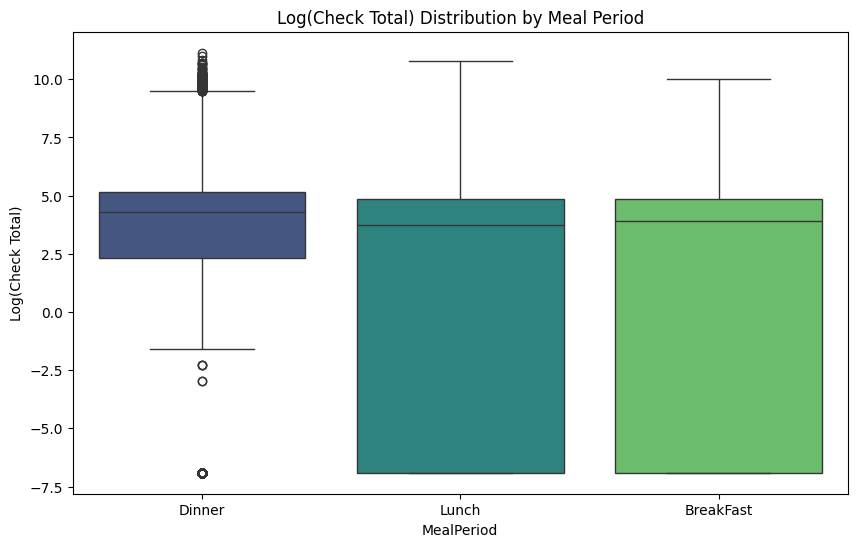

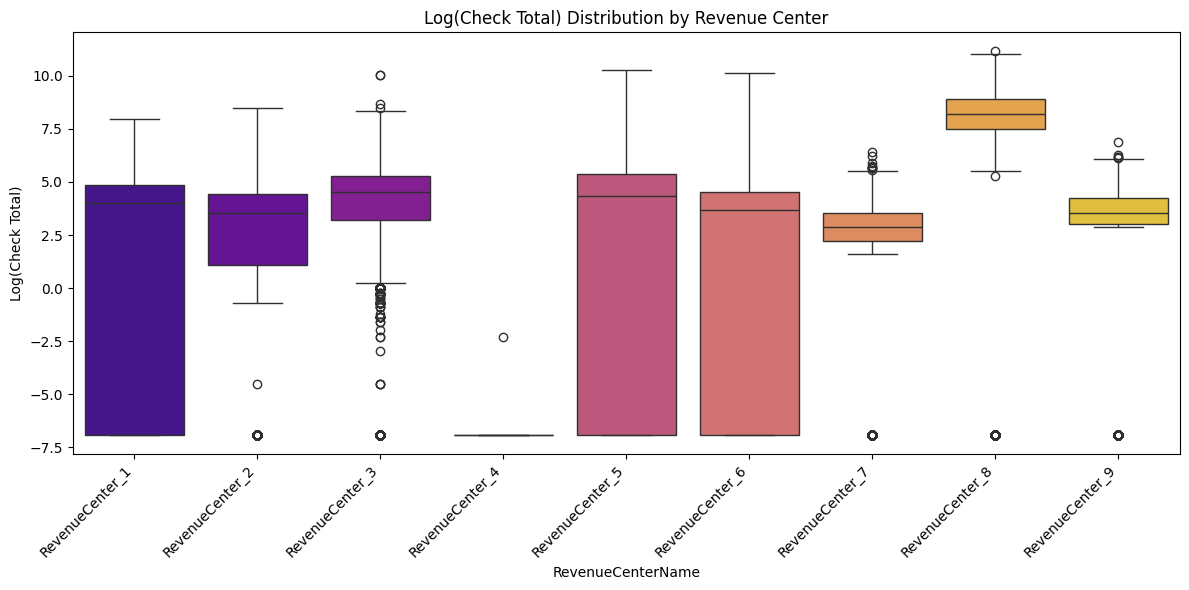

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

LOG_REVENUE_COLUMN = 'Log_Check_Total'

MEAL_PERIOD_COLUMN = 'MealPeriod' 
REVENUE_CENTER_COLUMN = 'RevenueCenterName' 

plt.figure(figsize=(10, 6))
sns.boxplot(x=MEAL_PERIOD_COLUMN, y=LOG_REVENUE_COLUMN, data=df, palette='viridis')
plt.title('Log(Check Total) Distribution by Meal Period')
plt.ylabel('Log(Check Total)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=REVENUE_CENTER_COLUMN, y=LOG_REVENUE_COLUMN, data=df, palette='plasma')
plt.title('Log(Check Total) Distribution by Revenue Center')
plt.ylabel('Log(Check Total)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generating Daily Trend Plot...


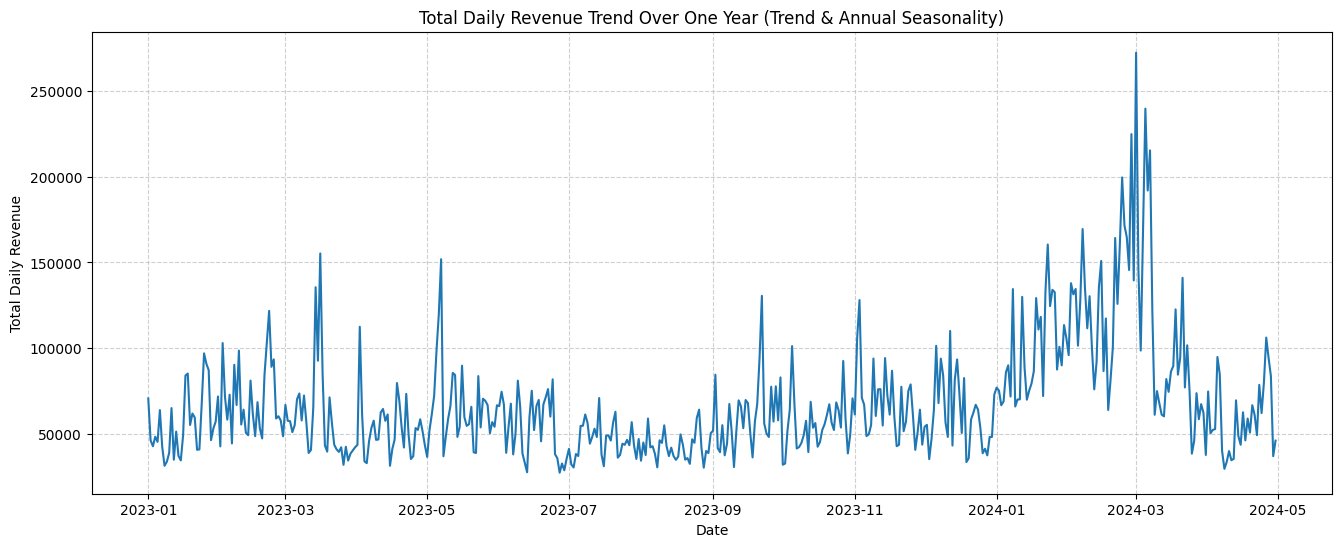

In [56]:
# ---  Daily Total Revenue Trend Over Time ---
REVENUE_COLUMN = 'CheckTotal'
# Aggregate transaction data to daily total revenue (using raw Check Total)
daily_revenue_df = df.groupby('DateKey')[REVENUE_COLUMN].sum().reset_index()
daily_revenue_df['DateKey'] = pd.to_datetime(daily_revenue_df['DateKey'])

print("Generating Daily Trend Plot...")
plt.figure(figsize=(16, 6))
sns.lineplot(x='DateKey', y=REVENUE_COLUMN, data=daily_revenue_df)
plt.title('Total Daily Revenue Trend Over One Year (Trend & Annual Seasonality)')
plt.xlabel('Date')
plt.ylabel('Total Daily Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Generating Weekly Seasonality Plot...


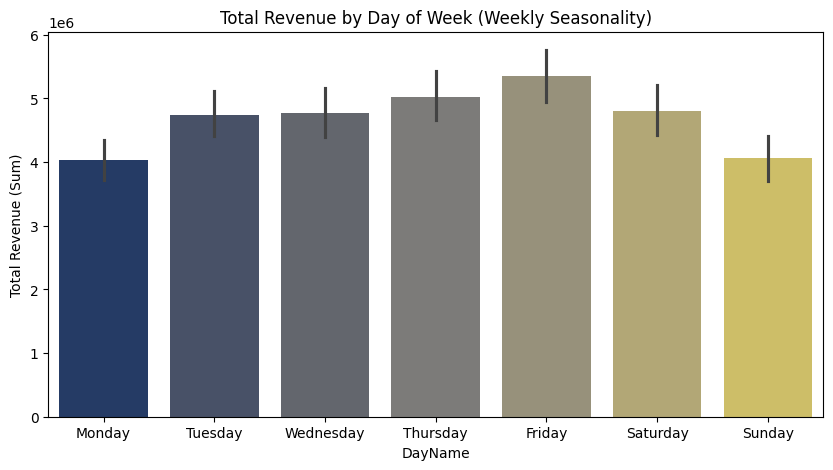

In [57]:
DATE_COLUMN = 'Date' 
REVENUE_COLUMN = 'CheckTotal' 

df['DayName'] = df[DATE_COLUMN].dt.day_name()

# ---  Run the Weekly Seasonality Plot ---
print("Generating Weekly Seasonality Plot...")

plt.figure(figsize=(10, 5))
sns.barplot(x='DayName', y=REVENUE_COLUMN, data=df, estimator=sum,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='cividis')
plt.title('Total Revenue by Day of Week (Weekly Seasonality)')
plt.ylabel('Total Revenue (Sum)')
plt.show()

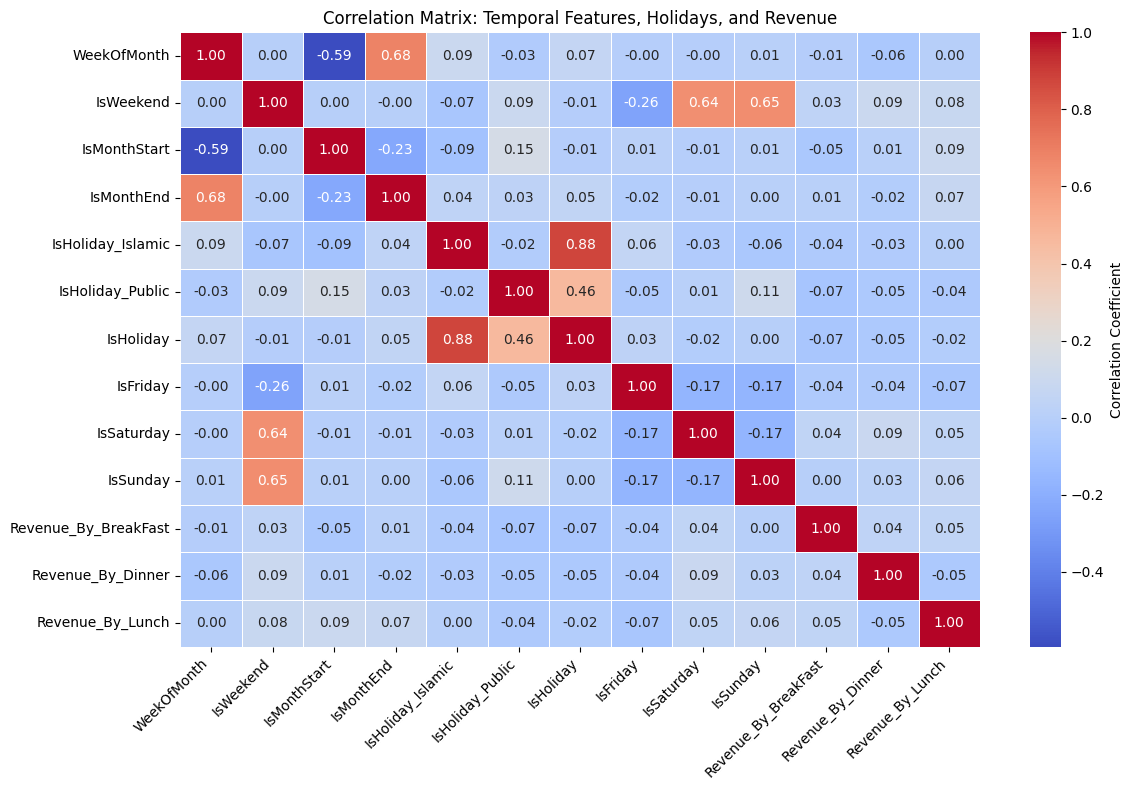

✅ Correlation matrix saved as 'correlation_matrix_temporal_holidays.png'.


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features that we want to correlate
correlation_features = [
    'WeekOfMonth', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsHoliday_Islamic', 
    'IsHoliday_Public', 'IsHoliday', 'IsFriday', 'IsSaturday', 'IsSunday',
    'Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch'
]

# Filter the DataFrame to include only the necessary columns
df_corr = df_final_report[correlation_features]

# Generate the correlation matrix
corr_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})

# Set the plot title and axis labels
plt.title('Correlation Matrix: Temporal Features, Holidays, and Revenue')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot as an image
plt.savefig('correlation_matrix_temporal_holidays.png')

# Display the plot
plt.show()

print("✅ Correlation matrix saved as 'correlation_matrix_temporal_holidays.png'.")
